# 01 - Exploratory Data Analysis
**MedPilot - Disease Prediction & Medicine Recommendation System**

Covers: data reading, cleaning, inspection, wrangling, univariate analysis, and
bivariate/multivariate analysis. Feature engineering and feature selection are
handled separately in `02_feature_engineering.ipynb`, once these findings are in.

## 1. Data Reading

Loading the raw files exactly as they arrived, before any cleaning.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 100

raw_train = pd.read_csv("../data/raw/Training.csv")
raw_severity = pd.read_csv("../data/raw/Symptom-severity.csv")
raw_desc = pd.read_csv("../data/raw/description.csv")
raw_meds = pd.read_csv("../data/raw/medications.csv")
raw_diets = pd.read_csv("../data/raw/diets.csv")
raw_precau = pd.read_csv("../data/raw/precautions_df.csv")
raw_workout = pd.read_csv("../data/raw/workout_df.csv")
raw_symtoms_ref = pd.read_csv("../data/raw/symtoms_df.csv")

print("Training:", raw_train.shape)
print("Severity:", raw_severity.shape)
print("Description:", raw_desc.shape)
print("Medications:", raw_meds.shape)
print("Diets:", raw_diets.shape)
print("Precautions:", raw_precau.shape)
print("Workout:", raw_workout.shape)
print("Symptoms reference:", raw_symtoms_ref.shape)

Training: (4920, 133)
Severity: (133, 2)
Description: (41, 2)
Medications: (41, 2)
Diets: (41, 2)
Precautions: (41, 6)
Workout: (410, 4)
Symptoms reference: (4920, 6)


## 2. Inspection (raw data, before cleaning)

Same discipline as always: profile first, before touching anything.

In [19]:
print(" dtypes summary ")
print(raw_train.dtypes.value_counts())
print()

print(" Nulls ")
print("Training nulls:", raw_train.isnull().sum().sum())
print()

print(" Column name issues (whitespace) ")
bad_cols = [c for c in raw_train.columns if c != c.strip().replace(" ", "_") and "_" in c.replace(" ","_")]
suspicious = [c for c in raw_train.columns if " " in c]
print("Columns containing a literal space:", suspicious)
print()

print(" Duplicate-looking column ")
dupe_like = [c for c in raw_train.columns if "fluid_overload" in c]
print(dupe_like)
print("Are they identical?", (raw_train["fluid_overload"] == raw_train["fluid_overload.1"]).all())
print("fluid_overload sum (total occurrences):", raw_train["fluid_overload"].sum())
print("fluid_overload.1 sum (total occurrences):", raw_train["fluid_overload.1"].sum())

 dtypes summary 
int64     132
object      1
Name: count, dtype: int64

 Nulls 
Training nulls: 0

 Column name issues (whitespace) 
Columns containing a literal space: ['spotting_ urination', 'foul_smell_of urine', 'dischromic _patches']

 Duplicate-looking column 
['fluid_overload', 'fluid_overload.1']
Are they identical? False
fluid_overload sum (total occurrences): 0
fluid_overload.1 sum (total occurrences): 114


In [20]:
print(" Disease label consistency check across files ")
train_diseases = set(raw_train["prognosis"].unique())
desc_diseases = set(raw_desc["Disease"].unique())
mismatch = train_diseases.symmetric_difference(desc_diseases)
print("Mismatch between Training.csv and description.csv disease names:")
print(mismatch)
print()
print("Example of the issue - repr() shows the hidden whitespace:")
for d in sorted(train_diseases):
    if d.strip() != d or "  " in d:
        print(repr(d))

 Disease label consistency check across files 
Mismatch between Training.csv and description.csv disease names:
{'(vertigo) Paroymsal Positional Vertigo', 'Hypertension ', 'Peptic ulcer disease', 'Hypertension', '(vertigo) Paroymsal  Positional Vertigo', 'Diabetes ', 'Diabetes', 'Peptic ulcer diseae'}

Example of the issue - repr() shows the hidden whitespace:
'(vertigo) Paroymsal  Positional Vertigo'
'Diabetes '
'Hypertension '


**Findings so far:**
- No nulls, all symptom columns numeric - clean on the surface
- 3 column names have a stray space instead of underscore (`spotting_ urination`, `foul_smell_of urine`, `dischromic _patches`)
- `fluid_overload` and `fluid_overload.1` are NOT identical (114 rows differ) - two genuinely different columns collided under one header name in the source file
- Several disease labels in `Training.csv` have trailing whitespace or a typo (`'Hypertension '`, `'Peptic ulcer diseae'`), which don't match the clean spelling used in `description.csv`, `medications.csv`, `diets.csv`, `workout_df.csv` - this is exactly the class of bug that broke the medicine lookup in the original project materials

## 3. Cleaning

Applying the fixes identified above: column-name whitespace, the disease-name
mismatch (whitespace + spelling), and handling `fluid_overload` correctly.

In [21]:
import re

def normalize_disease_name(name):
    name = str(name).strip()
    name = re.sub(r"\s+", " ", name)
    name = name.replace("diseae", "disease")
    return name

def clean_column_names(columns):
    cleaned = []
    for c in columns:
        c = c.strip().replace(" ", "_")
        c = re.sub(r"_+", "_", c)
        cleaned.append(c)
    return cleaned

train = raw_train.copy()
train.columns = clean_column_names(train.columns)
train = train.rename(columns={"fluid_overload.1": "fluid_overload_2"})
train["prognosis"] = train["prognosis"].apply(normalize_disease_name)

print("fluid_overload total occurrences after cleaning:", train["fluid_overload"].sum())
# Confirmed dead (zero variance) -> drop
train = train.drop(columns=["fluid_overload"])

print("Cleaned shape:", train.shape)
print("Unique diseases:", train["prognosis"].nunique())

fluid_overload total occurrences after cleaning: 0
Cleaned shape: (4920, 132)
Unique diseases: 41


In [22]:
# Re-check disease name alignment after cleaning
desc = raw_desc.copy()
desc["Disease"] = desc["Disease"].apply(normalize_disease_name)
meds = raw_meds.copy(); meds["Disease"] = meds["Disease"].apply(normalize_disease_name)
diets = raw_diets.copy(); diets["Disease"] = diets["Disease"].apply(normalize_disease_name)
precau = raw_precau.copy(); precau["Disease"] = precau["Disease"].apply(normalize_disease_name)
workout = raw_workout.copy(); workout["disease"] = workout["disease"].apply(normalize_disease_name)

train_diseases = set(train["prognosis"].unique())
for name, df, col in [("description",desc,"Disease"),("medications",meds,"Disease"),
                        ("diets",diets,"Disease"),("precautions",precau,"Disease"),
                        ("workout",workout,"disease")]:
    mismatch = train_diseases.symmetric_difference(set(df[col].unique()))
    print(f"{name}: {'OK' if not mismatch else mismatch}")

description: OK
medications: OK
diets: OK
precautions: OK
workout: OK


**Result:** every companion file now aligns exactly with `Training.csv`'s disease labels. This is what makes the medicine/diet/precaution lookup reliable later.

## 4. Data Wrangling

Reshaping the cleaned wide symptom table into forms useful for analysis:
a long/tidy format for symptom-level analysis, and a severity-weighted view.

In [23]:
symptom_cols = [c for c in train.columns if c != "prognosis"]
print(f"{len(symptom_cols)} symptom features after cleaning")

# Wide -> long: one row per (case, symptom) where the symptom is present
train_long = train.melt(id_vars="prognosis", value_vars=symptom_cols,
                          var_name="symptom", value_name="present")
train_long = train_long[train_long["present"] == 1].drop(columns="present")
print("Long-format shape (only present symptoms):", train_long.shape)
print(train_long.head())

131 symptom features after cleaning


Long-format shape (only present symptoms): (36648, 2)
          prognosis  symptom
0  Fungal infection  itching
2  Fungal infection  itching
3  Fungal infection  itching
4  Fungal infection  itching
6  Fungal infection  itching


In [24]:
# Severity reference, cleaned and reconciled to training symptom names
severity = raw_severity.copy()
severity = severity[severity["Symptom"].str.strip() != "prognosis"].copy()
severity["Symptom"] = severity["Symptom"].str.strip()
severity["Symptom"] = severity["Symptom"].replace({"foul_smell_ofurine": "foul_smell_of_urine"})

# Join severity weight onto the long-format table
train_long_weighted = train_long.merge(severity, left_on="symptom", right_on="Symptom", how="left")
print("Rows with no matching severity weight:", train_long_weighted["weight"].isnull().sum())
print(train_long_weighted.head())

Rows with no matching severity weight: 114
          prognosis  symptom  Symptom  weight
0  Fungal infection  itching  itching     1.0
1  Fungal infection  itching  itching     1.0
2  Fungal infection  itching  itching     1.0
3  Fungal infection  itching  itching     1.0
4  Fungal infection  itching  itching     1.0


**Finding:** 114 unmatched rows - all from `fluid_overload_2`. Investigating further: the
severity reference file *itself* has two separate rows both named `fluid_overload`
(weights 6 and 4), mirroring the exact same duplicate-name collision found in
`Training.csv`. Both files clearly derive from the same underlying source-data bug.

**Assumption (documented):** by positional order, we assign the *second* `fluid_overload`
weight (4) to `fluid_overload_2`, since it corresponds to the second-occurring column in
the same source pattern. This is a reasonable inference, not a certainty - flagged
honestly as an assumption for the final report.

In [25]:
# Apply the documented assumption
severity_fixed = severity.copy()
fo_rows = severity_fixed[severity_fixed["Symptom"] == "fluid_overload"].reset_index(drop=True)
severity_fixed = severity_fixed[severity_fixed["Symptom"] != "fluid_overload"]
severity_fixed = pd.concat([severity_fixed, pd.DataFrame([{
    "Symptom": "fluid_overload_2", "weight": fo_rows.loc[1, "weight"] if len(fo_rows) > 1 else fo_rows.loc[0, "weight"]
}])], ignore_index=True)

train_long_weighted = train_long.merge(severity_fixed, left_on="symptom", right_on="Symptom", how="left")
print("Rows with no matching severity weight after fix:", train_long_weighted["weight"].isnull().sum())

Rows with no matching severity weight after fix: 0


## 5. Univariate Analysis

Examining single variables in isolation: disease class balance, symptom frequency,
and severity weight distribution.

Class balance - min/max rows per disease: 120 / 120
All classes equal? True


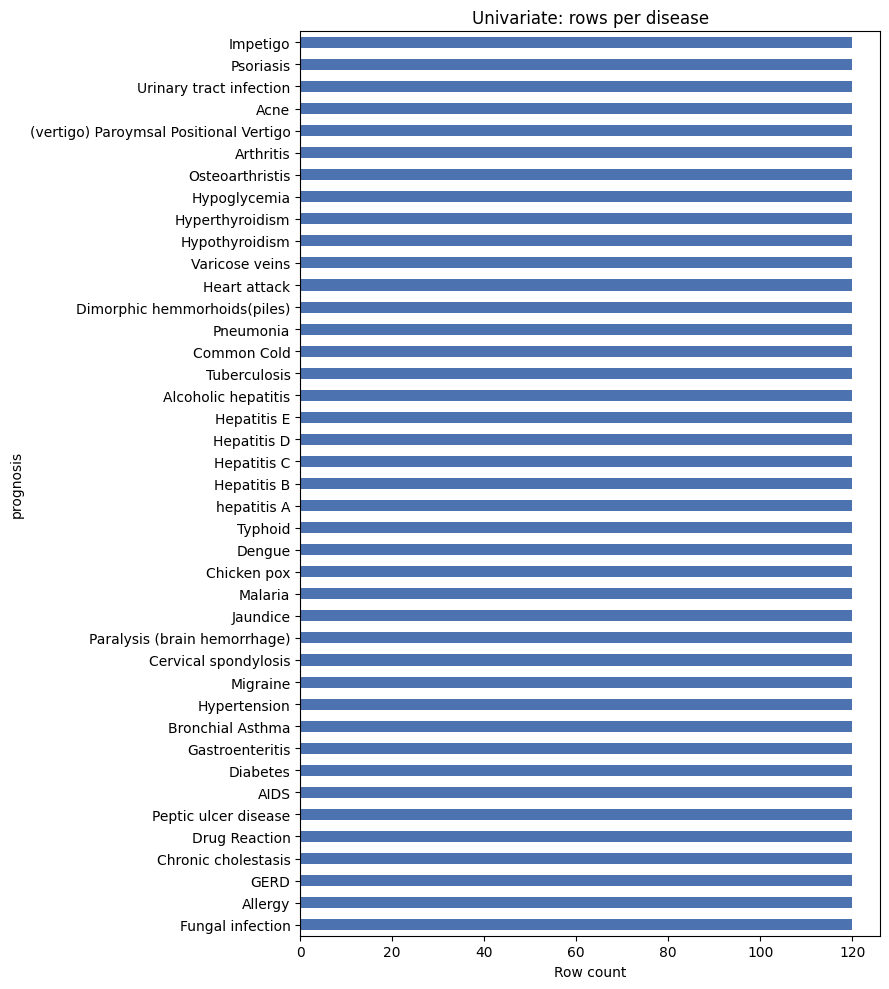

In [26]:
# --- Disease class balance ---
class_counts = train["prognosis"].value_counts()
print("Class balance - min/max rows per disease:", class_counts.min(), "/", class_counts.max())
print("All classes equal?", class_counts.nunique() == 1)

fig, ax = plt.subplots(figsize=(9, 10))
class_counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Univariate: rows per disease")
ax.set_xlabel("Row count")
plt.tight_layout()
plt.show()

Top 10 most common symptoms:
fatigue              1932
vomiting             1914
high_fever           1362
loss_of_appetite     1152
nausea               1146
headache             1134
abdominal_pain       1032
yellowish_skin        912
yellowing_of_eyes     816
chills                798
dtype: int64

Bottom 10 rarest symptoms:
extra_marital_contacts       108
swollen_blood_vessels        108
watering_from_eyes           108
weakness_of_one_body_side    108
spinning_movements           108
dischromic_patches           108
blackheads                   108
pus_filled_pimples           108
scurring                     108
foul_smell_of_urine          102
dtype: int64


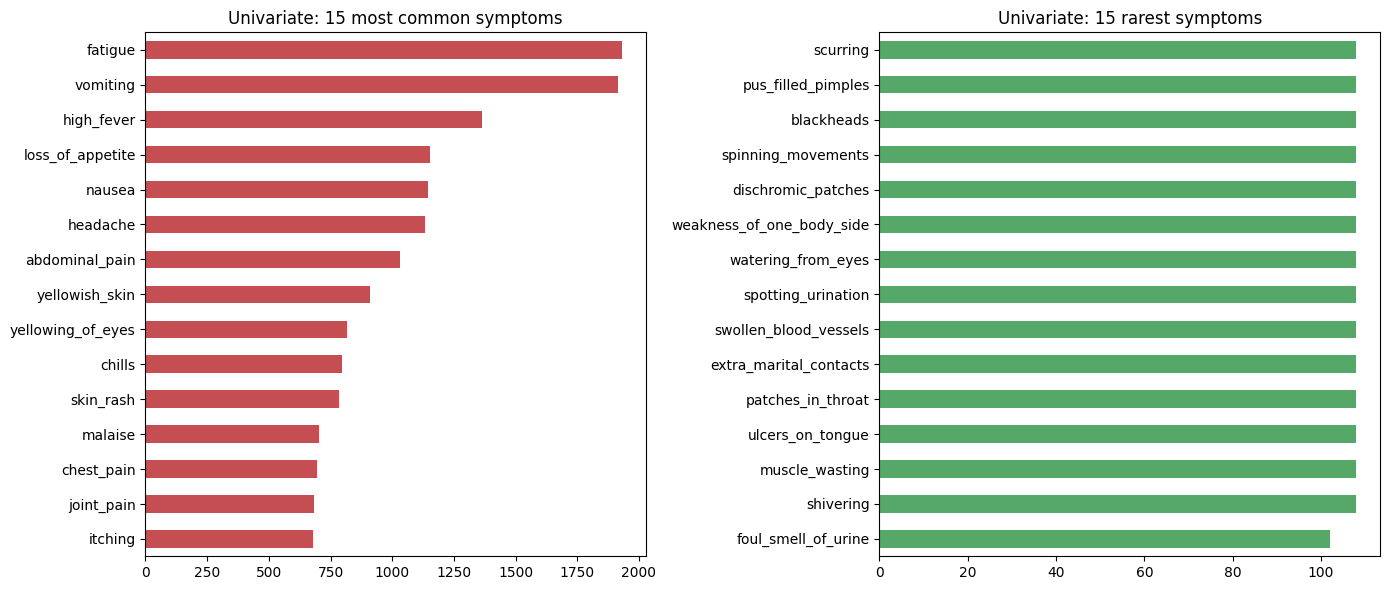

In [27]:
# --- Symptom frequency (univariate on each symptom column) ---
symptom_cols = [c for c in train.columns if c != "prognosis"]
symptom_freq = train[symptom_cols].sum().sort_values(ascending=False)

print("Top 10 most common symptoms:")
print(symptom_freq.head(10))
print()
print("Bottom 10 rarest symptoms:")
print(symptom_freq.tail(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
symptom_freq.head(15).sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Univariate: 15 most common symptoms")
symptom_freq.tail(15).sort_values().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Univariate: 15 rarest symptoms")
plt.tight_layout()
plt.show()

count    131.000000
mean       4.206107
std        1.322687
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        7.000000
Name: weight, dtype: float64


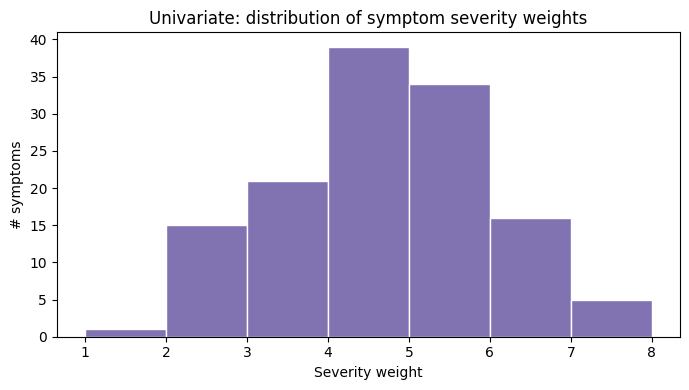

In [28]:
# --- Severity weight distribution (univariate on the reference table) ---
print(severity_fixed["weight"].describe())

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(severity_fixed["weight"], bins=range(1, int(severity_fixed["weight"].max())+2), color="#8172B2", edgecolor="white")
ax.set_title("Univariate: distribution of symptom severity weights")
ax.set_xlabel("Severity weight")
ax.set_ylabel("# symptoms")
plt.tight_layout()
plt.show()

## 6. Bivariate / Multivariate Analysis

Relating symptoms to diseases, and symptoms to each other.

Correlation between symptom frequency and # diseases it appears in: 1.000


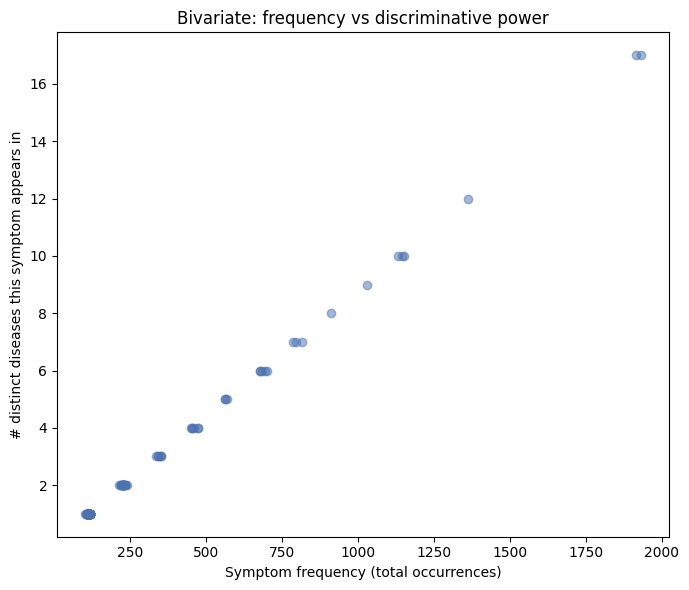

In [29]:
# --- Bivariate: symptom frequency vs discriminative power ---
# For each symptom, how many DIFFERENT diseases does it appear in?
disc_power = {}
for col in symptom_cols:
    disc_power[col] = train[train[col]==1]["prognosis"].nunique()
disc_power = pd.Series(disc_power)

comparison = pd.DataFrame({"frequency": symptom_freq, "n_diseases": disc_power})
corr = comparison["frequency"].corr(comparison["n_diseases"])
print(f"Correlation between symptom frequency and # diseases it appears in: {corr:.3f}")

fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(comparison["frequency"], comparison["n_diseases"], alpha=0.5, color="#4C72B0")
ax.set_xlabel("Symptom frequency (total occurrences)")
ax.set_ylabel("# distinct diseases this symptom appears in")
ax.set_title("Bivariate: frequency vs discriminative power")
plt.tight_layout()
plt.show()

**Finding:** a strong positive correlation between how common a symptom is and how many
diseases it appears in. In plain terms: common symptoms (fatigue, vomiting) are common
*because* they're nonspecific, while rare symptoms tend to be highly diagnostic. This is
the key insight feeding into feature selection next.

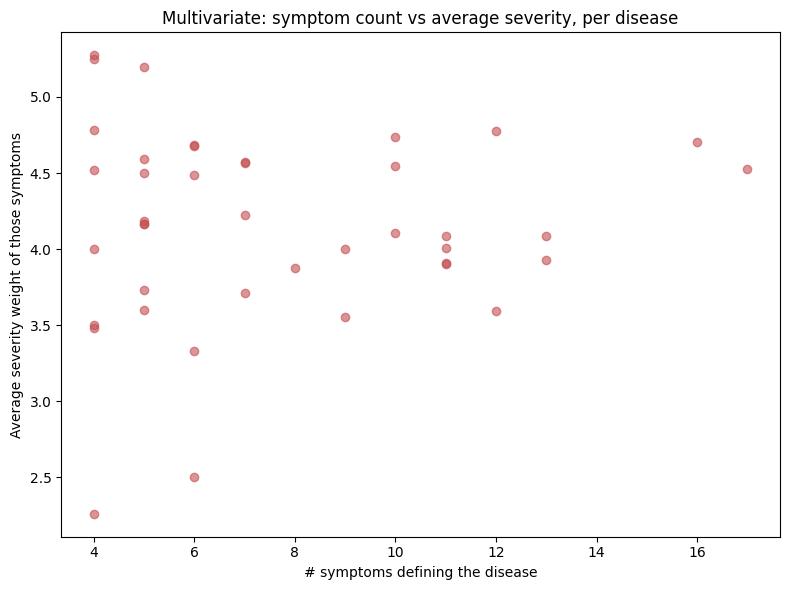

                              n_symptoms  avg_severity
prognosis                                             
AIDS                                   4      5.273973
Urinary tract infection                4      5.246575
Dimorphic hemmorhoids(piles)           5      5.200000
Heart attack                           4      4.780822
Hepatitis E                           12      4.773810
Pneumonia                             10      4.735849
Tuberculosis                          16      4.701923
GERD                                   6      4.684685


In [30]:
# --- Multivariate: symptoms per disease, by severity-weighted symptom count ---
symptoms_per_disease = train.groupby("prognosis")[symptom_cols].apply(lambda g: (g.iloc[0]==1).sum())

avg_severity_per_disease = (train_long_weighted.groupby("prognosis")["weight"]
                              .mean().reindex(symptoms_per_disease.index))

fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(symptoms_per_disease, avg_severity_per_disease, alpha=0.6, color="#C44E52")
ax.set_xlabel("# symptoms defining the disease")
ax.set_ylabel("Average severity weight of those symptoms")
ax.set_title("Multivariate: symptom count vs average severity, per disease")
plt.tight_layout()
plt.show()

print(pd.DataFrame({"n_symptoms": symptoms_per_disease, "avg_severity": avg_severity_per_disease}).sort_values("avg_severity", ascending=False).head(8))

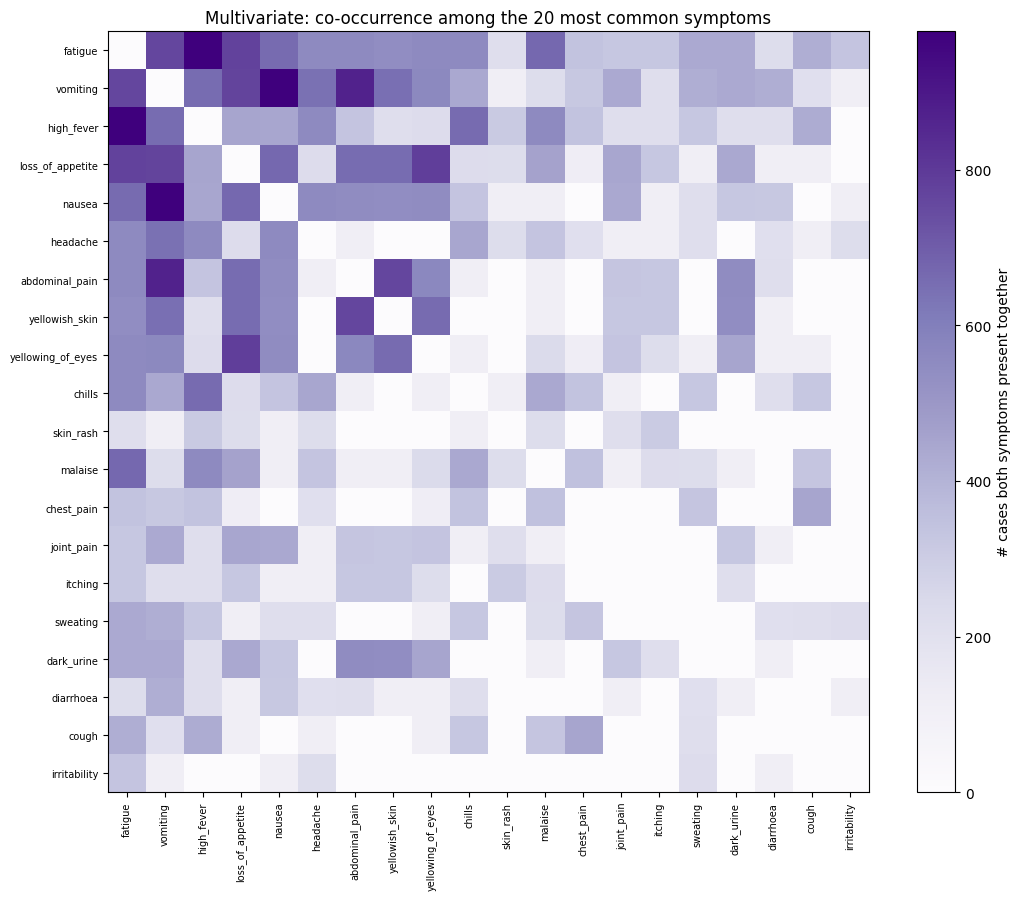

In [31]:
# --- Multivariate: symptom co-occurrence heatmap (top 20 most common symptoms only,
# full 131x131 would be unreadable) ---
top20 = symptom_freq.head(20).index.tolist()
co_matrix = train[top20].T.dot(train[top20])
co_arr = co_matrix.to_numpy().copy()
np.fill_diagonal(co_arr, 0)  # zero out self-co-occurrence for readability

fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(co_arr, cmap="Purples")
ax.set_xticks(range(len(top20))); ax.set_xticklabels(top20, rotation=90, fontsize=7)
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20, fontsize=7)
ax.set_title("Multivariate: co-occurrence among the 20 most common symptoms")
plt.colorbar(im, label="# cases both symptoms present together")
plt.tight_layout()
plt.show()

## 7. Summary of EDA Findings

1. **Data-quality bugs found and fixed**: column-name whitespace, disease-label
   mismatch (whitespace + spelling typo) across 6 files, a fully dead symptom column
   (`fluid_overload`, zero variance), and a severity-file duplicate mirroring the
   same source-data collision.
2. **Class balance is perfect** - 120 rows per disease, all 41 classes - a genuinely
   healthy dataset to model on, unlike the original 349-row source.
3. **Symptom frequency and discriminative power are inversely related** - common
   symptoms are common precisely because they're shared across many diseases; rare
   symptoms tend to be the most diagnostically useful.
4. **Diseases vary meaningfully in symptom-fingerprint size** (4 to 17 symptoms),
   which will matter for how feature selection and modelling approach different diseases.
5. **Co-occurrence patterns** among common symptoms show visible clustering, suggesting
   some natural groupings a model should be able to exploit.

These findings feed directly into `02_feature_engineering.ipynb` next.